# The goal - to find which CSS attributes are correlated with each other.

Those that are correlated can be used to reduce the number of attributes in the fingerprint, because they provide similar information. This analysis can help in reducing the size of the fingerprint and improving its performance.

In [15]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from scipy.cluster.hierarchy import linkage, dendrogram

In [16]:
df = pd.read_parquet('2_after_feature_extraction/feature_matrix_media_calc.parquet')

In [17]:
css_cols = [
    col for col in df.columns
    if col.startswith('css:')
    and col != 'css:User-Agent'
    and (not col.startswith('css:font') or col == 'css:font_vector')
]

df_css = df[css_cols].copy()

In [18]:
df_css

,css:calc-10-width,css:calc-2-width,css:calc-3-width,css:calc-4-width,css:calc-5-width,css:calc-6-width,css:calc-7-width,css:calc-8-width,css:calc-9-width,css:env-1-height,...,css:media-4-width,css:media-5-width,css:media-6-width,css:media-7-width,css:media-8-width,css:media-9-width,css:px_per_px,css:viewport_height,css:viewport_width,css:font_vector
0,0.239583,7.937500,279.102000,6.496094,0.604167,938.685000,19.601600,139.102000,0.207031,136,...,32,68,20,1,8,5,1,8,12,000000010000000
1,0.239583,7.937500,279.102000,6.496094,0.604167,938.685000,19.601600,139.102000,0.207031,136,...,32,68,20,1,8,5,1,8,12,000000010000000
2,0.239583,7.937500,279.102000,6.496094,0.604167,938.685000,19.601600,139.102000,0.207031,136,...,32,68,20,1,8,5,1,8,12,000000010000000
3,50.033300,0.000000,94.483300,3.183330,0.000000,2107.983398,16.500000,0.000000,0.000000,136,...,32,68,20,1,10,5,1,8,12,111111101110111
4,5.602941,7.953125,274.921875,6.496094,0.370536,938.622253,19.651787,59.558338,0.327381,130,...,32,68,41,2,8,5,3,7,3,000000000001000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
917,5.602941,7.953125,274.924133,6.496094,0.370536,938.622253,19.651787,59.558338,0.327381,136,...,32,68,20,1,8,5,1,8,12,000000010000000
918,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,136,...,0,68,20,1,8,5,1,8,12,000000010000000
919,5.602941,7.953125,274.924133,6.496094,0.370536,938.622253,19.651787,59.558338,0.327381,136,...,32,68,20,1,8,5,1,8,12,000000010000000
920,0.239583,7.937500,279.102000,6.496094,0.604167,938.685000,19.601600,139.102000,0.207031,136,...,32,68,20,1,8,5,1,9,9,001101000010100


In [19]:
# some rows have NaN values, which will cause issues with correlation matrix (espacially the image-set-href attribute)
df_css = df_css.replace(r'^\s*$', np.nan, regex=True)

In [20]:
corr_matrix = df_css.corr(method='pearson')

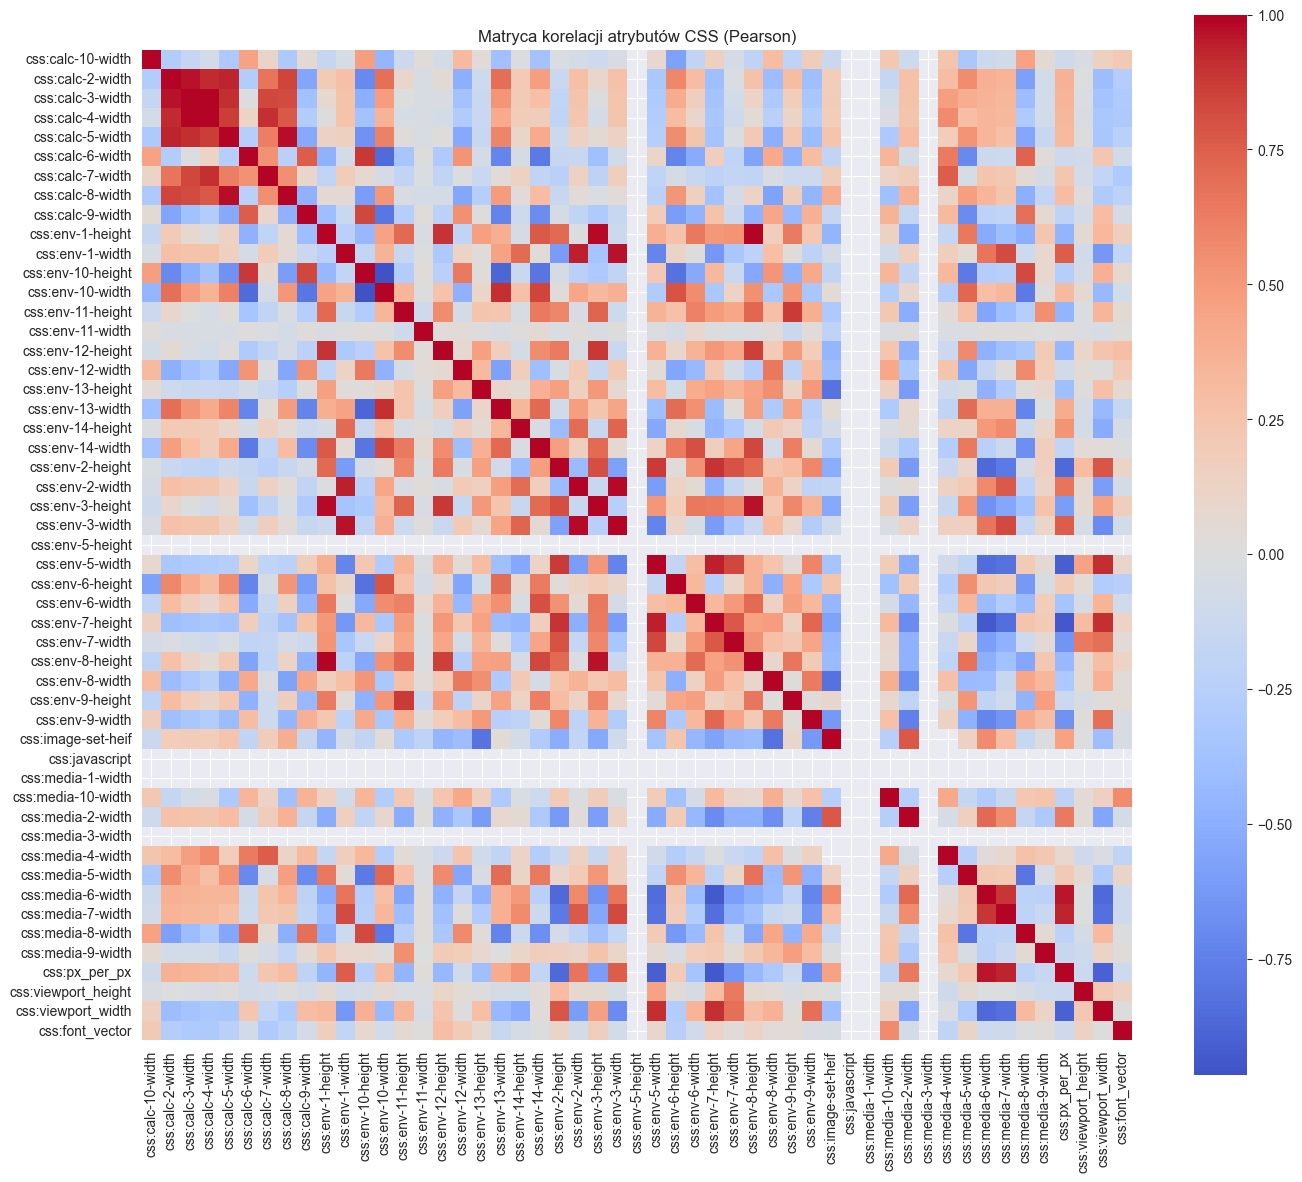

In [21]:
plt.figure(figsize=(14, 12))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, annot=False, fmt=".2f", square=True)
plt.title("Matryca korelacji atrybutów CSS (Pearson)")
plt.tight_layout()
plt.show()

In [22]:
threshold = 0.8  # High correlation threshold
high_corr = []

for col in corr_matrix.columns:
    for row in corr_matrix.index:
        if row != col and abs(corr_matrix.loc[row, col]) > threshold:
            pair = tuple(sorted((row, col)))
            if pair not in high_corr:
                high_corr.append(pair)

print(f"\\nHighly correlated CSS feature pairs (|r| > {threshold}):")
for a, b in sorted(high_corr):
    print(f"- {a} <--> {b} (r = {corr_matrix.loc[a, b]:.2f})")

\nHighly correlated CSS feature pairs (|r| > 0.8):
- css:calc-2-width <--> css:calc-3-width (r = 0.97)
- css:calc-2-width <--> css:calc-4-width (r = 0.92)
- css:calc-2-width <--> css:calc-5-width (r = 0.94)
- css:calc-2-width <--> css:calc-8-width (r = 0.84)
- css:calc-3-width <--> css:calc-4-width (r = 0.99)
- css:calc-3-width <--> css:calc-5-width (r = 0.91)
- css:calc-3-width <--> css:calc-7-width (r = 0.83)
- css:calc-3-width <--> css:calc-8-width (r = 0.82)
- css:calc-4-width <--> css:calc-5-width (r = 0.86)
- css:calc-4-width <--> css:calc-7-width (r = 0.90)
- css:calc-5-width <--> css:calc-8-width (r = 0.97)
- css:calc-6-width <--> css:env-10-height (r = 0.88)
- css:calc-6-width <--> css:env-10-width (r = -0.85)
- css:calc-9-width <--> css:env-10-height (r = 0.84)
- css:calc-9-width <--> css:env-10-width (r = -0.80)
- css:env-1-height <--> css:env-12-height (r = 0.89)
- css:env-1-height <--> css:env-3-height (r = 0.98)
- css:env-1-height <--> css:env-8-height (r = 0.99)
- css:en

In [23]:
# create a DataFrame with the high correlation pairs
high_corr_df = pd.DataFrame(high_corr, columns=['Feature A', 'Feature B'])
high_corr_df['Correlation'] = high_corr_df.apply(lambda row: corr_matrix.loc[row['Feature A'], row['Feature B']], axis=1)
high_corr_df

,Feature A,Feature B,Correlation
0,css:calc-2-width,css:calc-3-width,0.965333
1,css:calc-2-width,css:calc-4-width,0.919607
2,css:calc-2-width,css:calc-5-width,0.938350
3,css:calc-2-width,css:calc-8-width,0.840571
4,css:calc-3-width,css:calc-4-width,0.989929
5,css:calc-3-width,css:calc-5-width,0.910478
6,css:calc-3-width,css:calc-7-width,0.834302
7,css:calc-3-width,css:calc-8-width,0.819259
8,css:calc-4-width,css:calc-5-width,0.862526
9,css:calc-4-width,css:calc-7-width,0.902342


In [24]:
# get low correlation pairs
low_corr = []
for col in corr_matrix.columns:
    for row in corr_matrix.index:
        if row != col and abs(corr_matrix.loc[row, col]) < threshold:
            pair = tuple(sorted((row, col)))
            if pair not in low_corr:
                low_corr.append(pair)
print(f"\\nLow correlation CSS feature pairs (|r| < {threshold}):")
for a, b in sorted(low_corr):
    print(f"- {a} <--> {b} (r = {corr_matrix.loc[a, b]:.2f})")

\nLow correlation CSS feature pairs (|r| < 0.8):
- css:calc-10-width <--> css:calc-2-width (r = -0.28)
- css:calc-10-width <--> css:calc-3-width (r = -0.17)
- css:calc-10-width <--> css:calc-4-width (r = -0.08)
- css:calc-10-width <--> css:calc-5-width (r = -0.31)
- css:calc-10-width <--> css:calc-6-width (r = 0.45)
- css:calc-10-width <--> css:calc-7-width (r = 0.11)
- css:calc-10-width <--> css:calc-8-width (r = -0.31)
- css:calc-10-width <--> css:calc-9-width (r = 0.06)
- css:calc-10-width <--> css:env-1-height (r = -0.16)
- css:calc-10-width <--> css:env-1-width (r = -0.04)
- css:calc-10-width <--> css:env-10-height (r = 0.48)
- css:calc-10-width <--> css:env-10-width (r = -0.46)
- css:calc-10-width <--> css:env-11-height (r = -0.12)
- css:calc-10-width <--> css:env-11-width (r = 0.02)
- css:calc-10-width <--> css:env-12-height (r = -0.08)
- css:calc-10-width <--> css:env-12-width (r = 0.31)
- css:calc-10-width <--> css:env-13-height (r = 0.04)
- css:calc-10-width <--> css:env-13-w

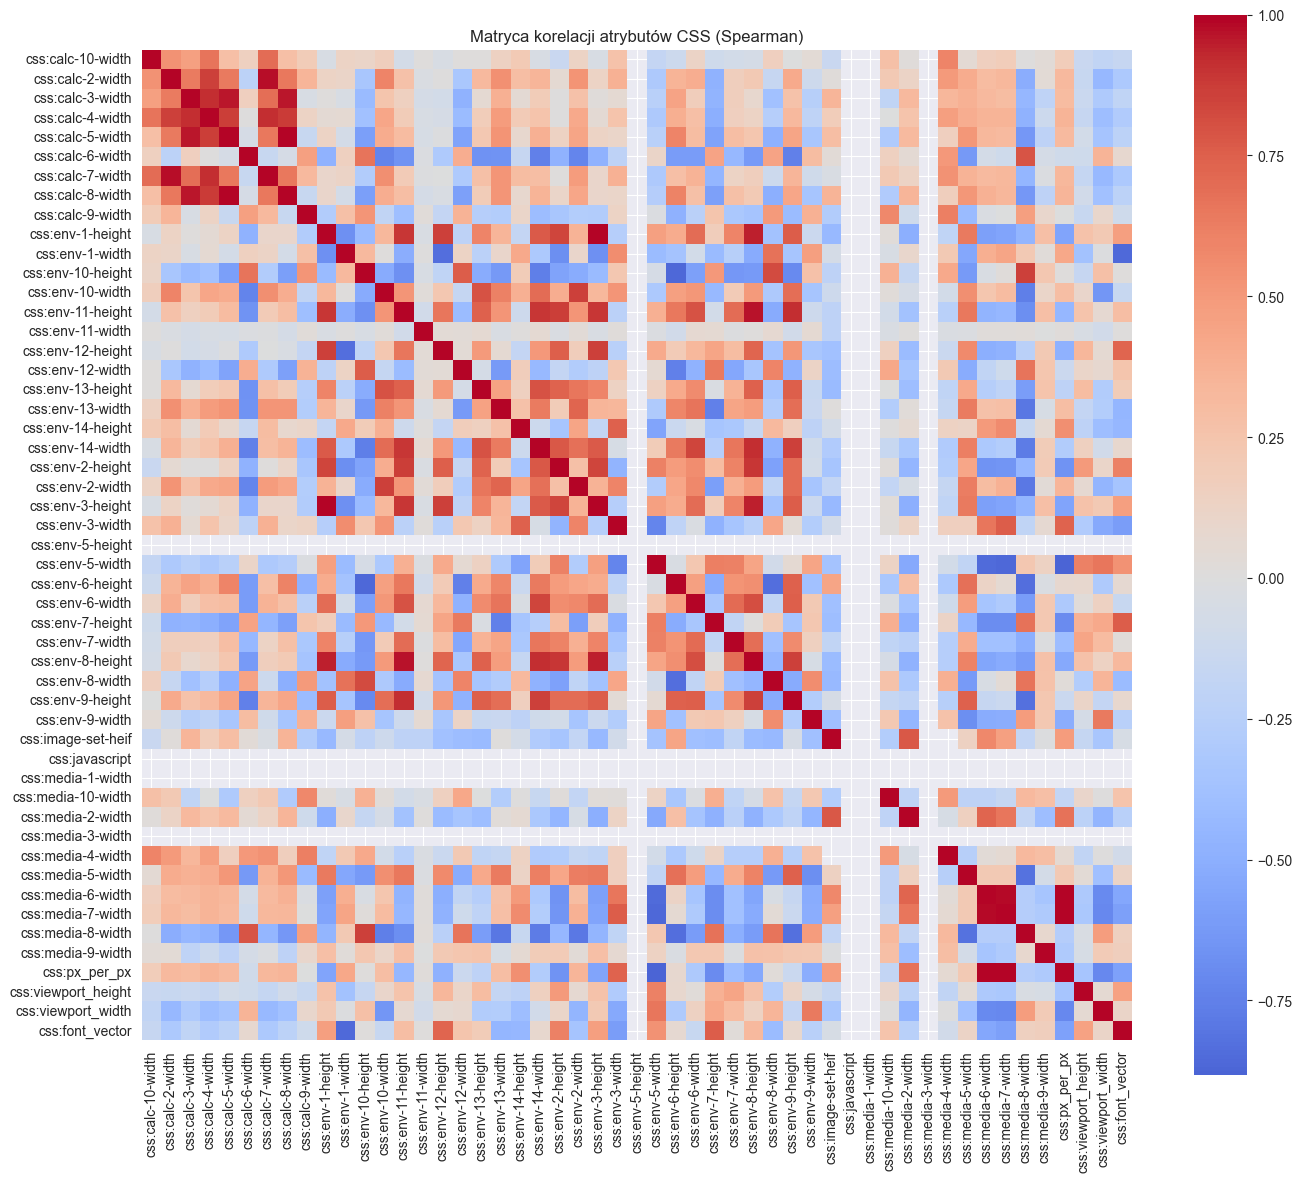

In [25]:
# create a spearman correlation matrix
corr_matrix_spearman = df_css.corr(method='spearman')
plt.figure(figsize=(14, 12))
sns.heatmap(corr_matrix_spearman, cmap='coolwarm', center=0, annot=False, fmt=".2f", square=True)
plt.title("Matryca korelacji atrybutów CSS (Spearman)")
plt.tight_layout()
plt.show()

In [26]:
def summarize_correlations(corr_matrix, thresholds=[0.9, 0.8, 0.7]):
    upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)).abs()
    n_features = corr_matrix.shape[0]
    total_pairs = (n_features * (n_features - 1)) / 2

    summary_data = []

    for t in thresholds:
        num_pairs = (upper_tri > t).sum().sum()
        percent = round(num_pairs / total_pairs * 100, 2)
        summary_data.append({
            'Próg': f'|r| > {t}',
            'Liczba par': num_pairs,
            'Liczba par względem wszystkich [%]': percent
        })

    # Add total count at the top
    summary_data.insert(0, {
        'Próg': 'brak',
        'Liczba par': int(total_pairs),
        'Liczba par względem wszystkich [%]': 100.0
    })

    return pd.DataFrame(summary_data)


In [27]:
summary_pearson = summarize_correlations(corr_matrix)
summary_spearman = summarize_correlations(corr_matrix_spearman)

In [28]:
print("Summary of Pearson Correlations:")
display(summary_pearson)

Summary of Pearson Correlations:


,Próg,Liczba par,Liczba par względem wszystkich [%]
0,brak,1275,100.00
1,|r| > 0.9,24,1.88
2,|r| > 0.8,60,4.71
3,|r| > 0.7,101,7.92


In [29]:
print("Summary of Spearman Correlations:")
display(summary_spearman)

Summary of Spearman Correlations:


,Próg,Liczba par,Liczba par względem wszystkich [%]
0,brak,1275,100.00
1,|r| > 0.9,15,1.18
2,|r| > 0.8,45,3.53
3,|r| > 0.7,88,6.90


In [30]:
def get_top_pairs(corr_matrix, top_n=10):
    upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    top_pairs = (
        upper_tri.stack()
        .sort_values(key=lambda x: abs(x), ascending=False)
        .head(top_n)
        .reset_index()
    )
    top_pairs.columns = ['Nazwa Atrybutu A', 'Nazwa Atrybutu B', 'Wskaźnik Korelacji']
    return top_pairs

In [31]:
print("Top 10 Pearson-correlated feature pairs:")
display(get_top_pairs(corr_matrix, top_n=10))

Top 10 Pearson-correlated feature pairs:


,Nazwa Atrybutu A,Nazwa Atrybutu B,Wskaźnik Korelacji
0,css:calc-3-width,css:calc-4-width,0.989929
1,css:env-1-height,css:env-8-height,0.989702
2,css:env-1-height,css:env-3-height,0.980889
3,css:env-2-width,css:env-3-width,0.978287
4,css:calc-5-width,css:calc-8-width,0.971469
5,css:env-3-height,css:env-8-height,0.967486
6,css:env-1-width,css:env-3-width,0.967130
7,css:env-10-height,css:env-10-width,-0.966373
8,css:calc-2-width,css:calc-3-width,0.965333
9,css:media-6-width,css:px_per_px,0.954666


In [32]:
print("Top 10 Spearman-correlated feature pairs:")
display(get_top_pairs(corr_matrix_spearman, top_n=10))

Top 10 Spearman-correlated feature pairs:


,Nazwa Atrybutu A,Nazwa Atrybutu B,Wskaźnik Korelacji
0,css:env-1-height,css:env-3-height,0.999869
1,css:calc-5-width,css:calc-8-width,0.996504
2,css:media-7-width,css:px_per_px,0.995345
3,css:media-6-width,css:px_per_px,0.989645
4,css:media-6-width,css:media-7-width,0.983248
5,css:calc-2-width,css:calc-7-width,0.973101
6,css:env-11-height,css:env-8-height,0.968669
7,css:calc-3-width,css:calc-8-width,0.961015
8,css:calc-3-width,css:calc-5-width,0.957655
9,css:env-1-height,css:env-8-height,0.943308


In [33]:
n_features = corr_matrix.shape[0]
total_pairs = (n_features * (n_features - 1)) / 2

summary_pearson['% of Pairs'] = (summary_pearson['Liczba par'] / total_pairs * 100).round(2)
summary_spearman['% of Pairs'] = (summary_spearman['Liczba par'] / total_pairs * 100).round(2)

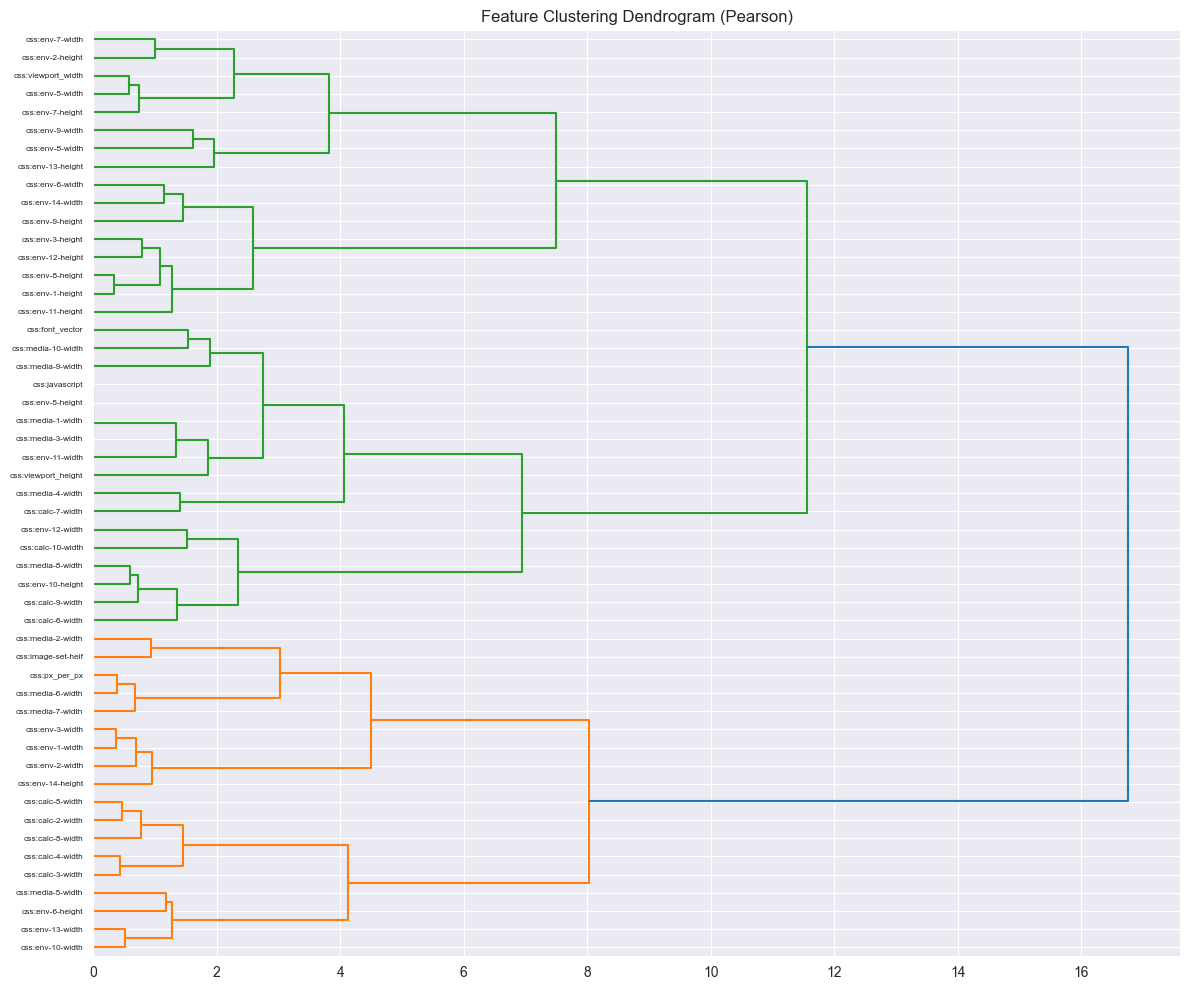

In [34]:
linked = linkage(corr_matrix.fillna(0), method='ward')
plt.figure(figsize=(12, 10))
dendrogram(linked, labels=corr_matrix.columns, orientation='right')
plt.title("Feature Clustering Dendrogram (Pearson)")
plt.tight_layout()
plt.show()

In [35]:
def get_redundant_features(corr_matrix, threshold=0.9):
    upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)).abs()
    redundant_pairs = upper_tri.stack()[lambda x: x > threshold]
    redundant_features = set()
    for i, j in redundant_pairs.index:
        redundant_features.add(j)  # arbitrarily drop one of the two
    return list(redundant_features)

In [36]:
redundant_features_pearson = get_redundant_features(corr_matrix, threshold=0.9)
print(f"Suggested features to drop (Pearson |r| > 0.9): {redundant_features_pearson}")

Suggested features to drop (Pearson |r| > 0.9): ['css:env-7-height', 'css:calc-5-width', 'css:px_per_px', 'css:viewport_width', 'css:calc-4-width', 'css:env-13-width', 'css:env-10-width', 'css:calc-7-width', 'css:calc-8-width', 'css:env-8-height', 'css:calc-3-width', 'css:env-2-width', 'css:media-6-width', 'css:env-3-height', 'css:env-3-width']


In [37]:
# the same for Spearman
redundant_features_spearman = get_redundant_features(corr_matrix_spearman, threshold=0.9)
print(f"Suggested features to drop (Spearman |r| > 0.9): {redundant_features_spearman}")

Suggested features to drop (Spearman |r| > 0.9): ['css:px_per_px', 'css:calc-5-width', 'css:calc-4-width', 'css:env-9-height', 'css:calc-7-width', 'css:calc-8-width', 'css:env-8-height', 'css:media-7-width', 'css:env-3-height']


In [38]:
def get_upper_triangle_df(corr_matrix_1, corr_matrix_2, name1="Pearson", name2="Spearman"):
    mask = np.triu(np.ones(corr_matrix_1.shape), k=1).astype(bool)
    feature_names = corr_matrix_1.columns

    df = pd.DataFrame({
        "Feature A": np.array(feature_names)[np.where(mask)[0]],
        "Feature B": np.array(feature_names)[np.where(mask)[1]],
        name1: corr_matrix_1.values[mask],
        name2: corr_matrix_2.values[mask]
    })

    return df

In [39]:
# Use your actual matrices here
correlation_pairs_df = get_upper_triangle_df(
    corr_matrix, corr_matrix_spearman,
    name1="Pearson", name2="Spearman"
)

# Confirm count
print(f"✅ Exporting {correlation_pairs_df.shape[0]} pairs (should be 1275 if 51 features)")

# Export to CSV
correlation_pairs_df.to_csv("correlation_pairs.csv", index=False)

✅ Exporting 1275 pairs (should be 1275 if 51 features)
